In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\kulka\Downloads\EDA Project\Bike_Sales.csv")
df

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,NaN,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,NaN,Commuter,Pearl White,100,electric,Manual,NaN,NaN,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,NaN,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,BS6 Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,BS6 Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,IND-15481,24-04-2023,Bajaj,CT110,Electric,Pearl White,0,BS6 Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,BS6 Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda Ltd,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,NaN,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,BS-6,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10620 entries, 0 to 10619
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               10620 non-null  object 
 1   Sale_Date              10620 non-null  object 
 2   Brand                  10620 non-null  object 
 3   Model                  9838 non-null   object 
 4   Category               10620 non-null  object 
 5   Color                  9840 non-null   object 
 6   Engine_CC              10620 non-null  int64  
 7   Fuel_Type              10620 non-null  object 
 8   Transmission           10620 non-null  object 
 9   Mileage_KMPL           6635 non-null   float64
 10  Ex_Showroom_Price_INR  9906 non-null   float64
 11  Discount_INR           9908 non-null   float64
 12  Units_Sold             10620 non-null  int64  
 13  Revenue_INR            10620 non-null  int64  
 14  State                  10620 non-null  object 
 15  Ci

In [4]:
df.isna().sum()

Order_ID                    0
Sale_Date                   0
Brand                       0
Model                     782
Category                    0
Color                     780
Engine_CC                   0
Fuel_Type                   0
Transmission                0
Mileage_KMPL             3985
Ex_Showroom_Price_INR     714
Discount_INR              712
Units_Sold                  0
Revenue_INR                 0
State                       0
City                        0
Sales_Channel             737
Customer_Segment            0
Payment_Method            735
Customer_Rating           769
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(420)

# Outliers

In [6]:
def outlier_detection_IQR(df,column):
    q1=df[column].quantile(0.25)
    q3=df[column].quantile(0,75)

    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr

    outliers=df[(df[column]<lower) | (df[column]>upper)]

    return outliers

In [7]:
df

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,NaN,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,NaN,Commuter,Pearl White,100,electric,Manual,NaN,NaN,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,NaN,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,BS6 Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,BS6 Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,IND-15481,24-04-2023,Bajaj,CT110,Electric,Pearl White,0,BS6 Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,BS6 Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda Ltd,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,NaN,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,BS-6,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


In [8]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10620 entries, 0 to 10619
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               10620 non-null  object 
 1   Sale_Date              10620 non-null  object 
 2   Brand                  10620 non-null  object 
 3   Model                  9838 non-null   object 
 4   Category               10620 non-null  object 
 5   Color                  9840 non-null   object 
 6   Engine_CC              10620 non-null  int64  
 7   Fuel_Type              10620 non-null  object 
 8   Transmission           10620 non-null  object 
 9   Mileage_KMPL           6635 non-null   float64
 10  Ex_Showroom_Price_INR  9906 non-null   float64
 11  Discount_INR           9908 non-null   float64
 12  Units_Sold             10620 non-null  int64  
 13  Revenue_INR            10620 non-null  int64  
 14  State                  10620 non-null  object 
 15  Ci

,Engine_CC,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,Customer_Rating
count,10620.000000,6635.000000,9.906000e+03,9908.000000,10620.000000,1.062000e+04,9851.000000
mean,270.138889,54.505837,3.586488e+05,7607.083470,16.246798,1.538415e+06,4.197351
std,244.910021,45.355155,3.779429e+06,41421.540087,274.803257,1.478400e+06,4.667512
min,0.000000,-30.000000,-5.000000e+04,-5000.000000,-5.000000,4.270000e+04,-5.000000
25%,110.000000,40.800000,9.370000e+04,2000.000000,4.000000,5.384000e+05,3.500000
50%,160.000000,52.200000,1.476000e+05,5000.000000,8.000000,1.044000e+06,4.000000
75%,390.000000,63.800000,2.482000e+05,10000.000000,12.000000,1.988000e+06,4.500000
max,1000.000000,999.000000,1.000000e+08,999999.000000,9999.000000,8.943000e+06,100.000000


# Duplicates

In [9]:
df.duplicated().sum()

np.int64(420)

In [10]:
df[df.duplicated()]

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
325,IND-13209,02-04-2023,Yamaha,Ray ZR,Scooter,Lime Green,110,Electric,Manual,NaN,72000.0,7000.0,5,325000,Maharashtra,Mumbai,Company Direct,Delivery Executive,UPI,4.4
837,IND-20024,21-06-2022,Suzuki,Burgman Street,Adventure,Lime Green,300,BS6 Petrol,Manual,38.0,217400.0,5000.0,9,1911600,Gujarat,Ahmedabad,Company Direct,Businessman,UPI,4.5
869,IND-11406,05-11-2021,Hero,HF Deluxe,Adventure,Racing Blue,300,Petrol,Manual,41.9,420700.0,10000.0,9,3696300,Delhi,New Delhi,Dealership,Delivery Executive,Credit Card,3.8
921,IND-18239,13-07-2023,Jawa,Perak,Cruiser,Pearl White,500,BS6 Petrol,Manual,51.3,245000.0,5000.0,5,1200000,West Bengal,Kolkata,NaN,Delivery Executive,Cash,3.9
1089,IND-10986,25-03-2022,Mahindra,Duro DZ,Commuter,Midnight Grey,150,Petrol,Manual,67.2,71100.0,7000.0,3,192300,Delhi,New Delhi,NaN,Homemaker,Cash,4.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10566,IND-16480,01-04-2022,Hero,Xtreme 160R,Electric,Midnight Grey,0,BS6 Petrol,Manual,43.3,114700.0,7000.0,7,753900,Uttar Pradesh,Lucknow,NaN,Delivery Executive,Credit Card,3.1
10570,IND-15268,14-04-2024,TVS,Jupiter,Scooter,Candy Yellow,150,PETROL,Manual,59.6,91300.0,10000.0,9,731700,Maharashtra,Mumbai,Exchange,Delivery Executive,Cash,4.2
10585,IND-13766,28-02-2024,TVS,Ntorq 125,Commuter,Pearl White,110,Petrol,Manual,42.2,79700.0,7000.0,15,1090500,Kerala,Kochi,Exchange,Student,Loan,3.3
10605,IND-19839,25-10-2022,tvs,iQube Electric,Scooter,Lime Green,150,Petrol,Manual,68.7,83300.0,10000.0,7,513100,Uttar Pradesh,Lucknow,Dealership,Homemaker,UPI,NaN


In [11]:
df[df.duplicated(subset=['Brand','Model','Category'])]

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
41,IND-10732,04-11-2021,Suzuki,V-Strom 650,Sports,Midnight Grey,200,Electric,Manual,NaN,116900.0,10000.0,11,1175900,Tamil Nadu,Chennai,Exchange,Homemaker,Loan,3.2
44,IND-19482,11-04-2023,Mahindra,Duro DZ,Commuter,Racing Blue,100,BS6 Petrol,Manual,70.0,NaN,NaN,2,156400,Kerala,Kochi,Exchange,Student,Cash,4.1
50,IND-10630,29-05-2022,Jawa,Jawa 42,Scooter,Glossy Red,150,Petrol,Manual,61.3,119100.0,5000.0,7,798700,Gujarat,Ahmedabad,Company Direct,Working Professional,Credit Card,3.1
60,IND-20024,21-06-2022,Suzuki,Burgman Street,Adventure,Lime Green,300,BS6 Petrol,Manual,38.0,217400.0,5000.0,9,1911600,Gujarat,Ahmedabad,Company Direct,Businessman,UPI,4.5
62,IND-13122,23-08-2022,Bajaj,Platina 110,Commuter,Candy Yellow,150,Electric,Manual,NaN,58700.0,2000.0,6,340200,delhi,New Delhi,Company Direct,Student,Credit Card,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10614,IND-13129,08-07-2023,Mahindra,Mojo 300,Adventure,Racing Blue,300,EV,Manual,NaN,299700.0,15000.0,5,1423500,Karnataka,Bengaluru,Exchange,Delivery Executive,Loan,3.4
10615,IND-15481,24-04-2023,Bajaj,CT110,Electric,Pearl White,0,BS6 Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,BS6 Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,BS-6,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


## Treat the duplicated rows by "dropping" them.

In [12]:
df.drop_duplicates(keep='first') 

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,NaN,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,NaN,Commuter,Pearl White,100,electric,Manual,NaN,NaN,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,NaN,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,BS6 Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,BS6 Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10614,IND-13129,08-07-2023,Mahindra,Mojo 300,Adventure,Racing Blue,300,EV,Manual,NaN,299700.0,15000.0,5,1423500,Karnataka,Bengaluru,Exchange,Delivery Executive,Loan,3.4
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,BS6 Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda Ltd,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,NaN,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,BS-6,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


In [13]:
df.drop_duplicates(keep='last') 

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,NaN,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,NaN,Commuter,Pearl White,100,electric,Manual,NaN,NaN,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,NaN,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,BS6 Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,BS6 Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,IND-15481,24-04-2023,Bajaj,CT110,Electric,Pearl White,0,BS6 Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,BS6 Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda Ltd,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,NaN,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,BS-6,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


# Inconsistant Data

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10620 entries, 0 to 10619
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Order_ID               10620 non-null  object 
 1   Sale_Date              10620 non-null  object 
 2   Brand                  10620 non-null  object 
 3   Model                  9838 non-null   object 
 4   Category               10620 non-null  object 
 5   Color                  9840 non-null   object 
 6   Engine_CC              10620 non-null  int64  
 7   Fuel_Type              10620 non-null  object 
 8   Transmission           10620 non-null  object 
 9   Mileage_KMPL           6635 non-null   float64
 10  Ex_Showroom_Price_INR  9906 non-null   float64
 11  Discount_INR           9908 non-null   float64
 12  Units_Sold             10620 non-null  int64  
 13  Revenue_INR            10620 non-null  int64  
 14  State                  10620 non-null  object 
 15  Ci

In [15]:
df

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,NaN,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,NaN,Commuter,Pearl White,100,electric,Manual,NaN,NaN,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,NaN,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,BS6 Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,BS6 Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,IND-15481,24-04-2023,Bajaj,CT110,Electric,Pearl White,0,BS6 Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,BS6 Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda Ltd,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,NaN,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,BS-6,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


In [16]:
df['Brand'].unique()

array(['KTM', 'Hero', 'Suzuki', 'Royal Enfield', 'HERO', 'Honda', 'TVS',
       'Jawa', 'Bajaj', 'Mahindra', 'Yamaha', 'T.V.S', 'honda', 'Hero ',
       'Honda Ltd', 'Bajaj Auto', 'TVS Motors', 'Royal Enfield India',
       'RE', 'tvs', 'Royal-Enfield', 'HONDA', 'royal enfield',
       'Hero Motocorp', 'bajaj', 'hero', 'BAJAJ'], dtype=object)

In [17]:
df['Brand'] = df['Brand'].map({
    'KTM':'KTM',
    'Hero':'Hero',
    'Suzuki':'Suzuki',
    'Royal Enfield':'Royal Enfield',
    'HERO':'Hero',
    'Jawa':'Jawa',
    'Mahindra':'Mahindra',
    'Yamaha':'YAMAHA',
    'honda':'Honda',
    'Honda Ltd':'Honda',
    'HONDA':'Honda',
    'TVS Motors':'TVS',
    'Royal Enfield India':'Royal Enfield',
    'RE':'Royal Enfield',
    'tvs':'TVS',
    'Royal-Enfield':'Royal Enfield',
    'royal enfield':'Royal Enfield',
    'Hero Motocorp':'Hero',
    'bajaj':'Bajaj',
    'hero':'Hero',
    'BAJAJ':'Bajaj',
    'Bajaj auto':'Bajaj',
    'Honda':'Honda',
    'T.V.S':'TVS',
    'TVS':'TVS'
})

In [18]:
df['Fuel_Type'] =df['Fuel_Type'].map({
    'Electric':'Electric',
    'electric':'Electric',
    'BS6 Petrol':'Petrol',
    'Petrol':'Petrol',
    'petrol':'Petrol'
})

In [19]:
df.isnull().sum()

Order_ID                    0
Sale_Date                   0
Brand                     978
Model                     782
Category                    0
Color                     780
Engine_CC                   0
Fuel_Type                 810
Transmission                0
Mileage_KMPL             3985
Ex_Showroom_Price_INR     714
Discount_INR              712
Units_Sold                  0
Revenue_INR                 0
State                       0
City                        0
Sales_Channel             737
Customer_Segment            0
Payment_Method            735
Customer_Rating           769
dtype: int64

In [20]:
df

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,NaN,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,NaN,Commuter,Pearl White,100,Electric,Manual,NaN,NaN,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,NaN,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,IND-15481,24-04-2023,NaN,CT110,Electric,Pearl White,0,Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,NaN,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,NaN,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


# Missing Values

In [21]:
df.isna()

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,False,False,True,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10616,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
10617,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
10618,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


In [22]:
df.isna().sum()

Order_ID                    0
Sale_Date                   0
Brand                     978
Model                     782
Category                    0
Color                     780
Engine_CC                   0
Fuel_Type                 810
Transmission                0
Mileage_KMPL             3985
Ex_Showroom_Price_INR     714
Discount_INR              712
Units_Sold                  0
Revenue_INR                 0
State                       0
City                        0
Sales_Channel             737
Customer_Segment            0
Payment_Method            735
Customer_Rating           769
dtype: int64

In [23]:
df.fillna({
    'Mileage_KMPL' : df['Mileage_KMPL'].median(),
    'Ex_Showroom_Price_INR':df['Ex_Showroom_Price_INR'].median(),
    'Discount_INR':df['Discount_INR'].median(),
    'Model':df['Model'].mode()[0],
    'Color':df['Color'].mode()[0],
    'Brand':df['Brand'].mode()[0],
    'Fuel_Type':df['Fuel_Type'].mode()[0],
     'Sales_Channel':df['Sales_Channel'].mode()[0],
    'Payment_Method':df['Payment_Method'].mode()[0],
    'Customer_Rating':df['Customer_Rating'].median()  
},inplace=True)

In [24]:
df.isna().sum()

Order_ID                 0
Sale_Date                0
Brand                    0
Model                    0
Category                 0
Color                    0
Engine_CC                0
Fuel_Type                0
Transmission             0
Mileage_KMPL             0
Ex_Showroom_Price_INR    0
Discount_INR             0
Units_Sold               0
Revenue_INR              0
State                    0
City                     0
Sales_Channel            0
Customer_Segment         0
Payment_Method           0
Customer_Rating          0
dtype: int64

# Data Manipulation

In [25]:
# 1 Filter applicants with Brand 'KTM'.
df[(df['Brand']=='KTM')]

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,52.2,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
14,IND-11426,04-10-2022,KTM,Duke 200,electric,Matte Black,0,Petrol,Manual,38.4,140700.0,10000.0,14,1829800,Uttar Pradesh,Lucknow,Dealership,Homemaker,EMI,4.2
18,IND-13138,25-10-2024,KTM,Adventure 390,Cruiser,Matte Black,350,Electric,Manual,52.2,163900.0,5000.0,5,794500,Kerala,Kochi,Company Direct,Delivery Executive,EMI,4.0
20,IND-19677,19-03-2023,KTM,Duke 390,Superbike,Racing Blue,650,Petrol,Manual,40.9,400900.0,10000.0,3,1172700,Tamil Nadu,Chennai,Company Direct,Working Professional,Loan,4.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10589,IND-19800,20-12-2021,KTM,Duke 200,Cruiser,Candy Yellow,500,Petrol,Manual,39.6,205700.0,10000.0,10,1957000,Delhi,New Delhi,Company Direct,Homemaker,UPI,5.0
10590,IND-16629,02-05-2024,KTM,Duke 390,Cruiser,Midnight Grey,350,Petrol,Manual,61.3,207100.0,5000.0,5,1010500,Tamil Nadu,Chennai,Exchange,Businessman,Credit Card,3.0
10595,IND-16138,24-05-2024,KTM,Adventure 390,Scooter,Midnight Grey,125,Petrol,Manual,43.7,76500.0,5000.0,2,143000,kerala,Kochi,Dealership,Homemaker,Loan,3.5
10598,IND-16942,19-11-2022,KTM,Duke 390,Cruiser,Midnight Grey,350,Petrol,Manual,52.8,165400.0,2000.0,9,1470600,Kerala,Kochi,Online,Delivery Executive,Loan,4.1


In [26]:
#2. Display rows where Transmission is Manual.
df[(df['Transmission']=='Manual')]

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,52.2,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,CB Unicorn,Commuter,Pearl White,100,Electric,Manual,52.2,147600.0,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,5000.0,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,IND-15481,24-04-2023,Honda,CT110,Electric,Pearl White,0,Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,147600.0,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,Petrol,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


In [27]:
# 3. Filter applicants who have Bajaj Bikes and BS6 Petrol.
df[(df['Brand']=='Bajaj') & (df['Fuel_Type']=='BS6 Petrol')]

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating


In [28]:
#4. Filter applicants where Payment_Method = 'EMI' and Sales_Channel = Dealership.
df[(df['Payment_Method']=='EMI') & (df['Sales_Channel']=='Dealership')]

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
14,IND-11426,04-10-2022,KTM,Duke 200,electric,Matte Black,0,Petrol,Manual,38.4,140700.0,10000.0,14,1829800,Uttar Pradesh,Lucknow,Dealership,Homemaker,EMI,4.2
17,IND-18645,20-01-2023,Suzuki,V-Strom 650,Sports,Matte Black,150,Electric,Manual,52.2,169800.0,2000.0,2,335600,Telangana,Hyderabad,Dealership,Working Professional,EMI,3.6
24,IND-17197,14-09-2021,KTM,RC 200,Commuter,Lime Green,100,Electric,Manual,52.2,73000.0,2000.0,13,923000,Tamil Nadu,Chennai,Dealership,Student,EMI,4.0
75,IND-19276,23-08-2021,Honda,Avenger 220,Adventure,Pearl White,390,Petrol,Manual,30.3,253800.0,5000.0,5,1244000,West Bengal,Kolkata,Dealership,Homemaker,EMI,4.7
87,IND-14701,01-01-2022,Suzuki,Gixxer 250,Superbike,Pearl White,1000,Petrol,Manual,52.2,360100.0,15000.0,9,3105900,Tamil Nadu,Chennai,Dealership,Homemaker,EMI,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10471,IND-15244,07-01-2022,Hero,Xtreme 160R,Scooter,Pearl White,110,Petrol,Manual,64.2,96400.0,0.0,14,1349600,Telangana,Hyderabad,Dealership,Businessman,EMI,3.2
10501,IND-18947,27-08-2022,Honda,Platina 110,Electric,Sunset Orange,0,Petrol,Manual,58.4,120700.0,3000.0,10,1177000,Telangana,Hyderabad,Dealership,Delivery Executive,EMI,3.7
10547,IND-10199,04-02-2022,Honda,Avenger 220,Sports,Candy Yellow,160,Electric,Manual,52.2,124500.0,3000.0,14,1701000,West Bengal,Kolkata,Dealership,Businessman,EMI,4.0
10608,IND-13453,19-05-2023,Jawa,42 Bobber,Electric,Matte Black,0,Petrol,Manual,32.3,104900.0,0.0,8,839200,Tamil Nadu,Chennai,Dealership,Delivery Executive,EMI,4.8


In [29]:
# 5. Display applicants where Discount_INR > 4000 and Customer_Rating < 3.
df[(df['Discount_INR']>4000) & (df['Customer_Rating']<3)]

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
186,IND-18981,23-08-2021,Mahindra,Centuro,Sports,Lime Green,160,Petrol,Manual,52.2,152700.0,7000.0,14,2039800,Karnataka,Bengaluru,Company Direct,Businessman,Credit Card,0.0
223,IND-16862,30-01-2024,Suzuki,Access 125,Cruiser,Midnight Grey,350,Petrol,Manual,35.8,188600.0,15000.0,11,1909600,Uttar Pradesh,Lucknow,Dealership,Homemaker,Credit Card,-5.0
503,IND-18280,21-08-2021,KTM,RC 200,Superbike,Matte Black,1000,Petrol,Manual,52.3,593900.0,15000.0,4,2315600,Karnataka,Bengaluru,Exchange,Delivery Executive,Cash,-5.0
1839,IND-18025,12-09-2022,YAMAHA,Ray ZR,Scooter,Pearl White,150,Petrol,Manual,32.2,81000.0,5000.0,15,1140000,Kerala,Kochi,Online,Businessman,Credit Card,0.0
2108,IND-16646,17-05-2021,Suzuki,Burgman Street,Commuter,Glossy Red,100,Petrol,Manual,36.0,70200.0,10000.0,5,301000,Delhi,New Delhi,Online,Student,Credit Card,-5.0
2163,IND-18036,29-06-2023,Jawa,Yezdi Scrambler,Adventure,Lime Green,300,Petrol,Manual,65.3,393500.0,10000.0,4,1534000,Gujarat,Ahmedabad,Company Direct,Working Professional,UPI,-1.0
2323,IND-18731,21-07-2023,Hero,Glamour,Commuter,Candy Yellow,150,Electric,Manual,52.2,89600.0,5000.0,9,761400,RAJASTHAN,Jaipur,Online,Homemaker,Credit Card,0.0
2440,IND-15010,06-10-2022,Suzuki,Gixxer 250,Commuter,Racing Blue,100,Petrol,Manual,62.1,147600.0,5000.0,3,254700,Delhi,New Delhi,Exchange,Working Professional,EMI,-5.0
3160,IND-18280,21-08-2021,KTM,RC 200,Superbike,Matte Black,1000,Petrol,Manual,52.3,593900.0,15000.0,4,2315600,Karnataka,Bengaluru,Exchange,Delivery Executive,Cash,-5.0
3669,IND-20083,31-01-2021,Hero,Glamour,Scooter,Sunset Orange,110,Electric,Manual,52.2,86400.0,5000.0,2,162800,RAJASTHAN,Jaipur,Company Direct,Homemaker,Cash,0.0


In [30]:
# 6. Show customers who are live in 'Maharashtra' AND done payment through Credit Card.
df[(df['State'] == 'Maharashtra') & (df['Payment_Method'] == 'Credit Card')]

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
8,IND-15080,22-03-2023,Hero,HF Deluxe,Scooter,Lime Green,110,Petrol,Manual,58.7,72500.0,10000.0,8,500000,Maharashtra,Mumbai,Company Direct,Working Professional,Credit Card,3.5
32,IND-12036,16-02-2024,YAMAHA,R15 V4,Adventure,Midnight Grey,390,Petrol,Manual,63.7,406300.0,3000.0,15,6049500,Maharashtra,Mumbai,Online,Homemaker,Credit Card,3.9
40,IND-10586,09-12-2021,YAMAHA,Ray ZR,Sports,Racing Blue,250,Petrol,Manual,73.3,172700.0,5000.0,1,167700,Maharashtra,Mumbai,Company Direct,Delivery Executive,Credit Card,4.3
45,IND-11457,16-09-2022,Suzuki,Burgman Street,Cruiser,Candy Yellow,220,Petrol,Manual,68.7,166400.0,0.0,4,665600,Maharashtra,Mumbai,Dealership,Businessman,Credit Card,4.1
205,IND-12914,21-02-2022,YAMAHA,Ray ZR,Superbike,Midnight Grey,390,Electric,Manual,52.2,543800.0,10000.0,4,2135200,Maharashtra,Mumbai,Exchange,Working Professional,Credit Card,4.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10474,IND-14424,30-10-2021,Jawa,Yezdi Scrambler,Electric,Midnight Grey,0,Petrol,Manual,59.0,99200.0,0.0,2,198400,Maharashtra,Mumbai,Dealership,Student,Credit Card,3.3
10539,IND-10824,02-06-2023,Hero,Passion Pro,Superbike,Lime Green,390,Electric,Manual,52.2,500500.0,5000.0,8,3964000,Maharashtra,Mumbai,Online,Working Professional,Credit Card,4.0
10545,IND-11152,16-11-2023,Honda,CB Unicorn,Sports,Midnight Grey,160,Petrol,Manual,51.5,199200.0,10000.0,6,1135200,Maharashtra,Mumbai,Exchange,Homemaker,Credit Card,3.2
10548,IND-19685,10-05-2023,Mahindra,Mojo 300,Superbike,Lime Green,1000,Petrol,Manual,67.7,314900.0,3000.0,8,2495200,Maharashtra,Mumbai,Exchange,Delivery Executive,Credit Card,3.5


In [31]:
# 7. Show customer who are Fuel_Type = 'Petrol'.
df.query("Fuel_Type=='Petrol'")

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,5000.0,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
5,IND-19323,21-06-2023,Hero,Passion Pro,Sports,Lime Green,150,Petrol,Manual,70.8,178500.0,7000.0,6,1029000,Tamil Nadu,Chennai,Online,Businessman,Credit Card,4.1
6,IND-13411,01-03-2021,Honda,Hornet 2.0,Adventure,Sunset Orange,390,Petrol,Manual,33.7,367400.0,15000.0,7,2466800,Rajasthan,Jaipur,Company Direct,Businessman,Credit Card,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10614,IND-13129,08-07-2023,Mahindra,Mojo 300,Adventure,Racing Blue,300,Petrol,Manual,52.2,299700.0,15000.0,5,1423500,Karnataka,Bengaluru,Exchange,Delivery Executive,Loan,3.4
10615,IND-15481,24-04-2023,Honda,CT110,Electric,Pearl White,0,Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,147600.0,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0


In [32]:
# 8. Filter records where Customer_Rating = 4.
df.query("Customer_Rating==4")

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
6,IND-13411,01-03-2021,Honda,Hornet 2.0,Adventure,Sunset Orange,390,Petrol,Manual,33.7,367400.0,15000.0,7,2466800,Rajasthan,Jaipur,Company Direct,Businessman,Credit Card,4.0
15,IND-13164,12-07-2024,Hero,Passion Pro,Cruiser,Sunset Orange,350,Petrol,Manual,70.8,186500.0,10000.0,3,529500,Kerala,Kochi,Exchange,Working Professional,Credit Card,4.0
16,IND-11417,01-12-2022,Honda,Pulsar NS200,Sports,Midnight Grey,200,Petrol,Manual,52.2,102900.0,7000.0,12,1150800,Maharashtra,Mumbai,Exchange,Delivery Executive,UPI,4.0
18,IND-13138,25-10-2024,KTM,Adventure 390,Cruiser,Matte Black,350,Electric,Manual,52.2,163900.0,5000.0,5,794500,Kerala,Kochi,Company Direct,Delivery Executive,EMI,4.0
21,IND-13751,07-05-2021,Honda,Avenger 220,Cruiser,Racing Blue,500,Electric,Manual,52.2,191000.0,15000.0,13,2288000,Gujarat,Ahmedabad,Exchange,Delivery Executive,Cash,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10561,IND-15449,02-09-2024,Honda,CB Unicorn,Sports,Matte Black,250,Electric,Manual,52.2,196200.0,7000.0,1,189200,Delhi,New Delhi,Company Direct,Businessman,UPI,4.0
10603,IND-19965,14-04-2024,Honda,Dominar 400,Sports,Pearl White,150,Petrol,Manual,52.3,9999999.0,0.0,14,1780800,Kerala,Kochi,Exchange,Delivery Executive,UPI,4.0
10605,IND-19839,25-10-2022,TVS,iQube Electric,Scooter,Lime Green,150,Petrol,Manual,68.7,83300.0,10000.0,7,513100,Uttar Pradesh,Lucknow,Dealership,Homemaker,UPI,4.0
10613,IND-14780,03-06-2023,Mahindra,Gusto 125,Sports,Midnight Grey,200,Petrol,Manual,35.1,145400.0,10000.0,2,270800,Delhi,New Delhi,Exchange,Student,EMI,4.0


In [33]:
# 9. Get customer where Discount > 5000.
df.query("Discount_INR>5000")

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
5,IND-19323,21-06-2023,Hero,Passion Pro,Sports,Lime Green,150,Petrol,Manual,70.8,178500.0,7000.0,6,1029000,Tamil Nadu,Chennai,Online,Businessman,Credit Card,4.1
6,IND-13411,01-03-2021,Honda,Hornet 2.0,Adventure,Sunset Orange,390,Petrol,Manual,33.7,367400.0,15000.0,7,2466800,Rajasthan,Jaipur,Company Direct,Businessman,Credit Card,4.0
8,IND-15080,22-03-2023,Hero,HF Deluxe,Scooter,Lime Green,110,Petrol,Manual,58.7,72500.0,10000.0,8,500000,Maharashtra,Mumbai,Company Direct,Working Professional,Credit Card,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10610,IND-15213,21-12-2022,Jawa,Jawa Classic,Adventure,Racing Blue,390,Petrol,Manual,53.1,287600.0,7000.0,8,2244800,Telangana,Hyderabad,Company Direct,Working Professional,UPI,3.1
10611,IND-15407,22-09-2024,Jawa,Jawa Classic,Sports,Midnight Grey,250,Petrol,Manual,999.0,105100.0,10000.0,3,285300,Uttar Pradesh,Lucknow,Company Direct,Delivery Executive,EMI,4.3
10612,IND-12099,29-09-2023,Royal Enfield,Himalayan,Commuter,Sunset Orange,150,Petrol,Manual,34.6,81200.0,15000.0,10,662000,West Bengal,Kolkata,Dealership,Businessman,Credit Card,4.3
10613,IND-14780,03-06-2023,Mahindra,Gusto 125,Sports,Midnight Grey,200,Petrol,Manual,35.1,145400.0,10000.0,2,270800,Delhi,New Delhi,Exchange,Student,EMI,4.0


In [34]:
# 10. Show Customer with Payment_Method = 'Loan' and Fuel_Type='Petrol'
df.query("Payment_Method=='Loan' & Fuel_Type=='Petrol'")

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
7,IND-16893,11-02-2021,Hero,Xtreme 160R,COMMUTER,Glossy Red,150,Petrol,Manual,35.8,70000.0,2000.0,3,204000,Kerala,Kochi,Company Direct,Student,Loan,4.5
9,IND-11950,14-07-2024,Suzuki,Burgman Street,Superbike,Racing Blue,1000,Petrol,Manual,69.3,147600.0,2000.0,13,7326800,Delhi,New Delhi,Online,Businessman,Loan,4.9
20,IND-19677,19-03-2023,KTM,Duke 390,Superbike,Racing Blue,650,Petrol,Manual,40.9,400900.0,10000.0,3,1172700,Tamil Nadu,Chennai,Company Direct,Working Professional,Loan,4.9
28,IND-18460,20-10-2023,YAMAHA,MT-15,Sports,Racing Blue,250,Petrol,Manual,60.3,185400.0,10000.0,6,1052400,Uttar Pradesh,Lucknow,Company Direct,Delivery Executive,Loan,5.0
36,IND-13117,19-12-2023,Royal Enfield,Classic 350,Commuter,Glossy Red,125,Petrol,Manual,31.7,74100.0,10000.0,7,448700,Delhi,New Delhi,Exchange,Businessman,Loan,3.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10595,IND-16138,24-05-2024,KTM,Adventure 390,Scooter,Midnight Grey,125,Petrol,Manual,43.7,76500.0,5000.0,2,143000,kerala,Kochi,Dealership,Homemaker,Loan,3.5
10596,IND-16035,20-10-2023,Hero,Passion Pro,Scooter,Sunset Orange,110,Petrol,Manual,69.5,70700.0,0.0,9,636300,telangana,Hyderabad,Exchange,Student,Loan,3.1
10598,IND-16942,19-11-2022,KTM,Duke 390,Cruiser,Midnight Grey,350,Petrol,Manual,52.8,165400.0,2000.0,9,1470600,Kerala,Kochi,Online,Delivery Executive,Loan,4.1
10614,IND-13129,08-07-2023,Mahindra,Mojo 300,Adventure,Racing Blue,300,Petrol,Manual,52.2,299700.0,15000.0,5,1423500,Karnataka,Bengaluru,Exchange,Delivery Executive,Loan,3.4


# Data Visualization

## Univariate Analysis

In [35]:
df

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,52.2,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,CB Unicorn,Commuter,Pearl White,100,Electric,Manual,52.2,147600.0,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,5000.0,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,IND-15481,24-04-2023,Honda,CT110,Electric,Pearl White,0,Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,147600.0,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,Petrol,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


<Axes: xlabel='Brand', ylabel='count'>

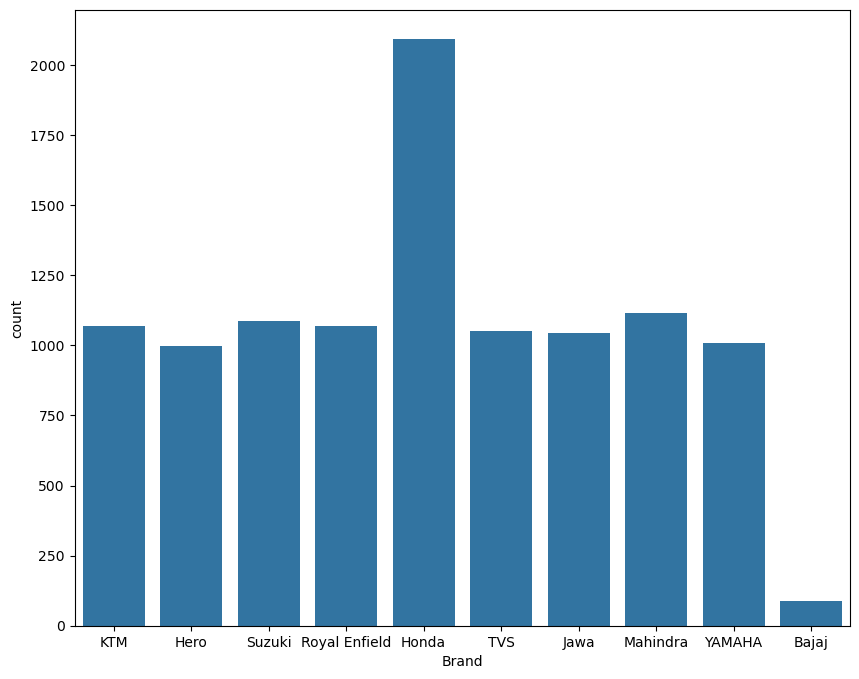

In [36]:
plt.figure(figsize=(10,8))
sns.countplot(x=df['Brand'])

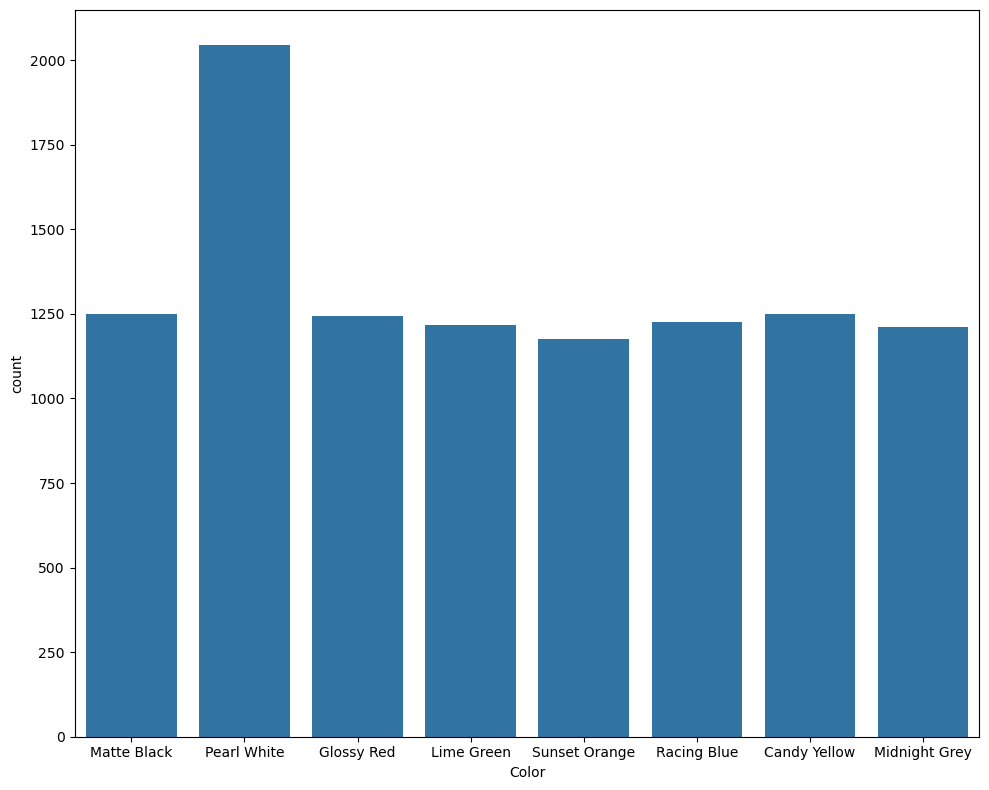

In [37]:
plt.figure(figsize=(10,8))
sns.countplot(x=df['Color'])
plt.tight_layout()

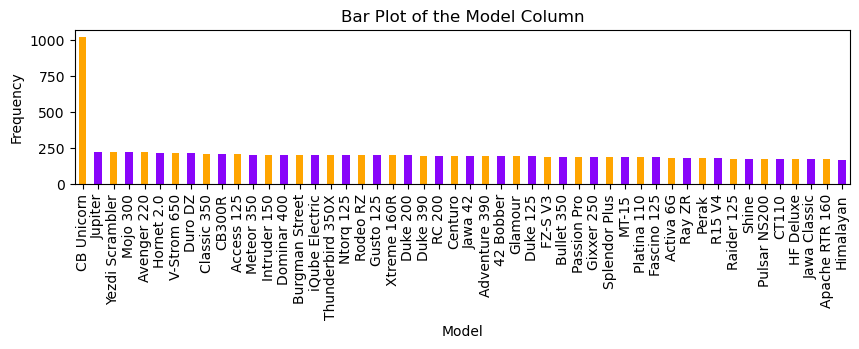

In [38]:
plt.figure(figsize=(10,2)) 
df['Model'].value_counts().plot(kind='bar',color=['orange','#8805fa'])

plt.xlabel("Model")

plt.ylabel("Frequency")

plt.title("Bar Plot of the Model Column")
plt.show() 

<Axes: xlabel='Brand'>

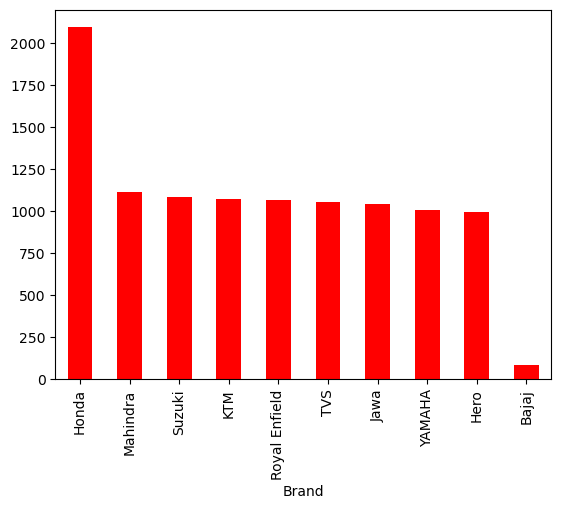

In [39]:
df['Brand'].value_counts().plot(kind='bar',color='red')

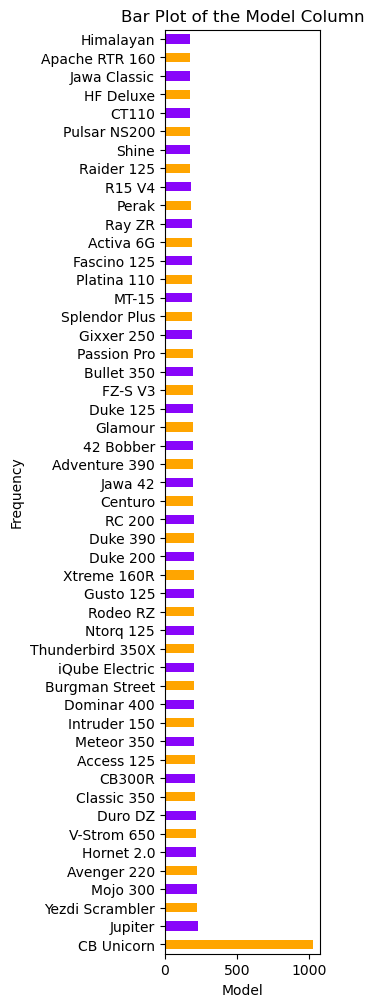

In [40]:
plt.figure(figsize=(2,12)) 
df['Model'].value_counts().plot(kind='barh',color=['orange','#8805fa'])

plt.xlabel("Model")

plt.ylabel("Frequency")

plt.title("Bar Plot of the Model Column")
plt.show() 

<Axes: ylabel='Model'>

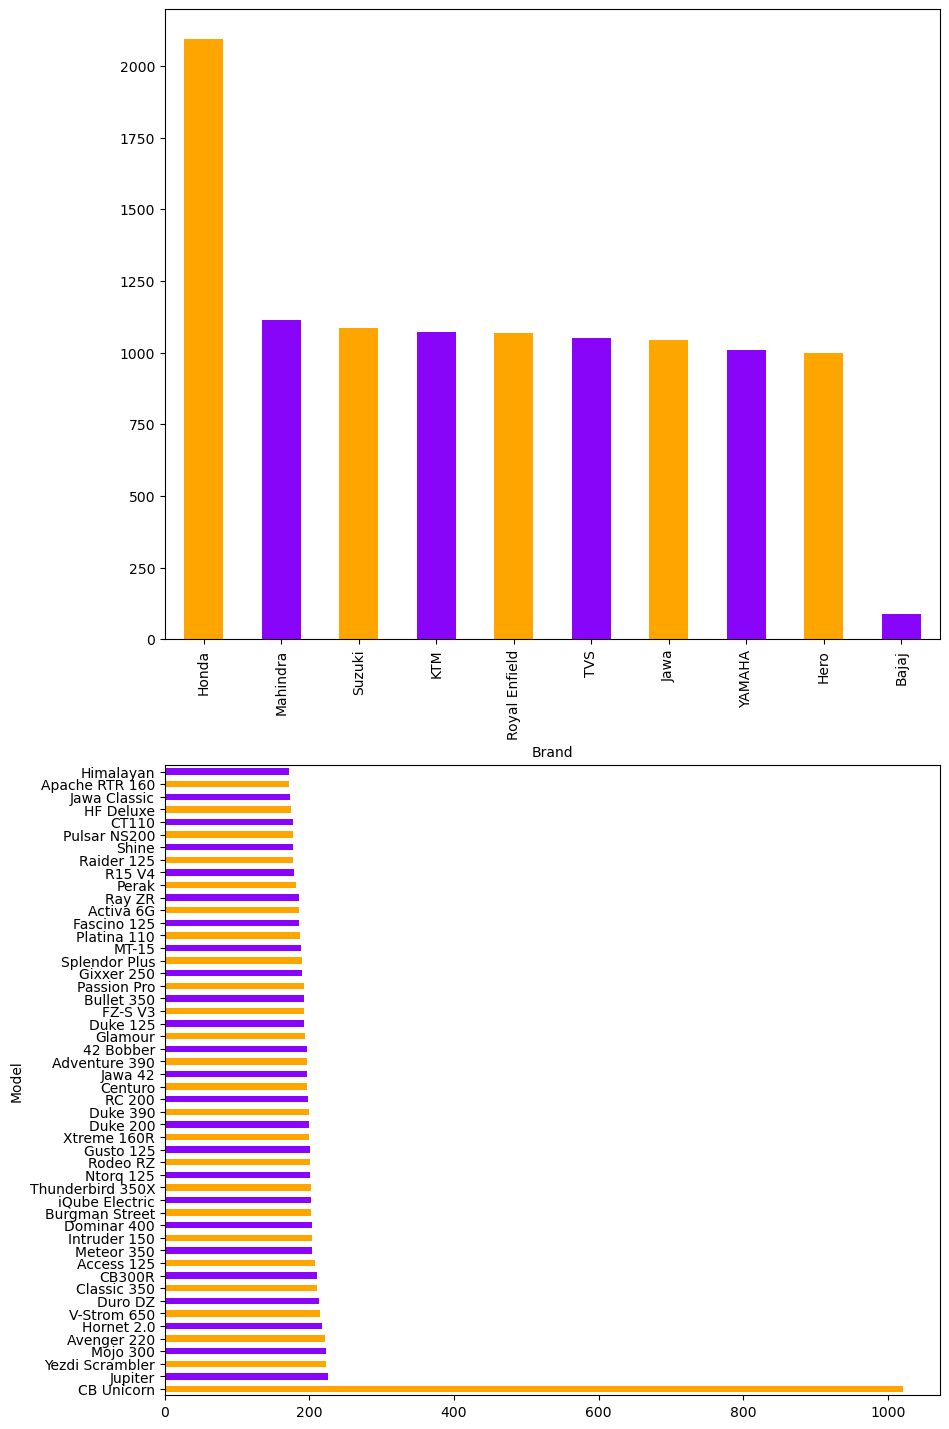

In [41]:
plt.figure(figsize=(10,18))

plt.subplot(2,1,1)
df['Brand'].value_counts().plot(kind='bar',color=['orange','#8805fa'])

plt.subplot(2,1,2)
df['Model'].value_counts().plot(kind='barh',color=['orange','#8805fa'])

In [42]:
df

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,52.2,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,CB Unicorn,Commuter,Pearl White,100,Electric,Manual,52.2,147600.0,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,5000.0,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10615,IND-15481,24-04-2023,Honda,CT110,Electric,Pearl White,0,Petrol,Manual,30.8,136800.0,2000.0,4,539200,West Bengal,Kolkata,Company Direct,Businessman,Credit Card,3.3
10616,IND-13829,04-01-2023,Honda,Shine,Cruiser,Pearl White,350,Petrol,Manual,67.7,177700.0,0.0,6,1066200,Uttar Pradesh,Lucknow,Exchange,Working Professional,Loan,3.1
10617,IND-11821,21-04-2022,Honda,Hornet 2.0,Scooter,Racing Blue,150,Petrol,Manual,53.4,147600.0,2000.0,14,1069600,Karnataka,Bengaluru,Exchange,Student,EMI,5.0
10618,IND-15073,25-09-2022,KTM,Adventure 390,Superbike,Glossy Red,390,Petrol,Manual,58.7,368200.0,-5000.0,14,5154800,Gujarat,Ahmedabad,Online,Working Professional,Cash,4.0


C:\Users\kulka\AppData\Local\Temp\ipykernel_28564\117978220.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Fuel_Type'],palette='bright')


<Axes: xlabel='Fuel_Type', ylabel='count'>

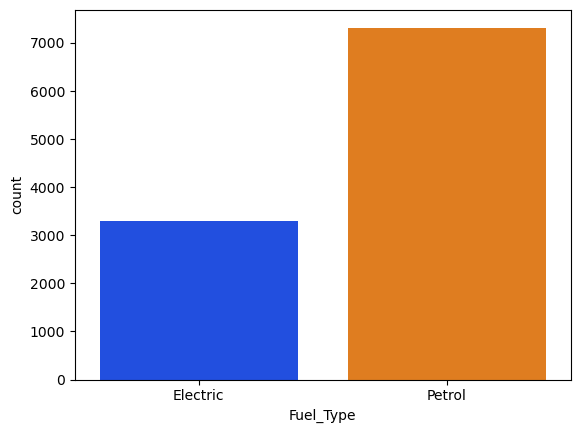

In [43]:
sns.countplot(x=df['Fuel_Type'],palette='bright')

C:\Users\kulka\AppData\Local\Temp\ipykernel_28564\2231503677.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Brand'],palette='pastel')


<Axes: xlabel='Brand', ylabel='count'>

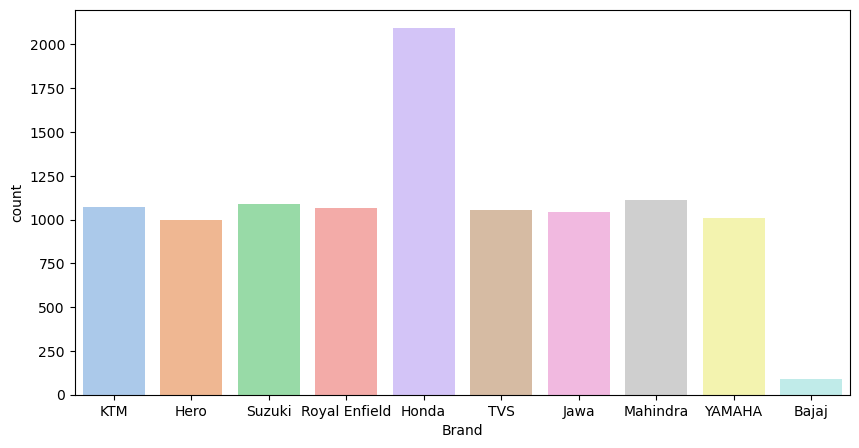

In [44]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['Brand'],palette='pastel') 

<Axes: ylabel='count'>

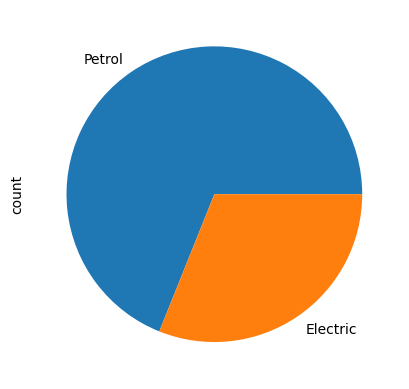

In [45]:
df['Fuel_Type'].value_counts().plot(kind='pie')

<Axes: ylabel='count'>

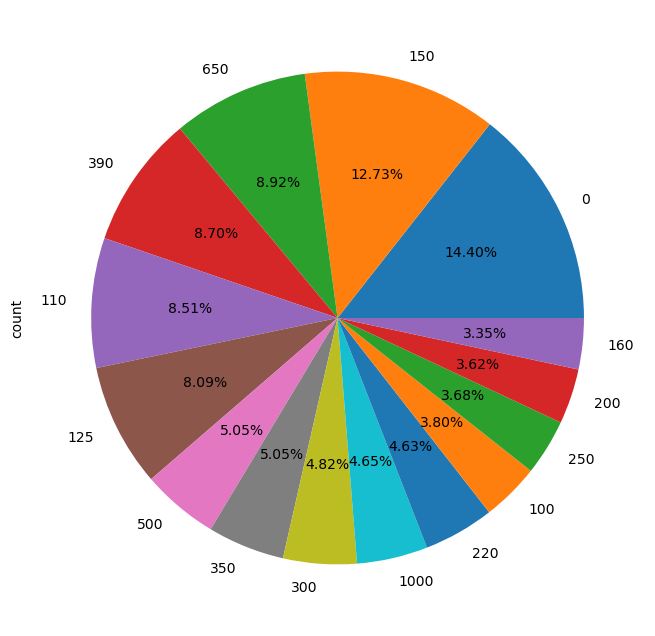

In [46]:
plt.figure(figsize=(8,8))
df['Engine_CC'].value_counts().plot(kind='pie',
                                  autopct='%.2f%%')

<Axes: ylabel='count'>

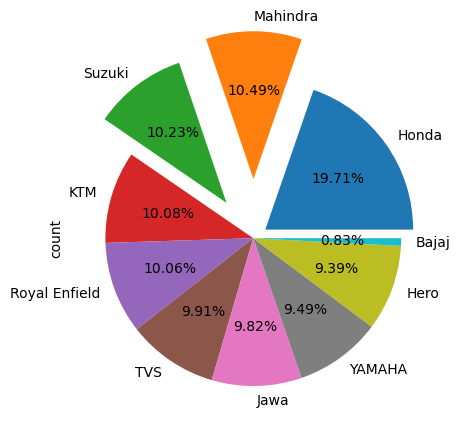

In [47]:
df['Brand'].value_counts().plot(kind='pie',
                              autopct='%.2f%%',
                              explode=[0.1,0.4,0.3,0,0,0,0,0,0,0])

# Bivariate

In [48]:
df.head()

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,52.2,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,CB Unicorn,Commuter,Pearl White,100,Electric,Manual,52.2,147600.0,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,5000.0,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4


Text(0.5, 1.0, 'Fuel_Type & Mileage_KMPL')

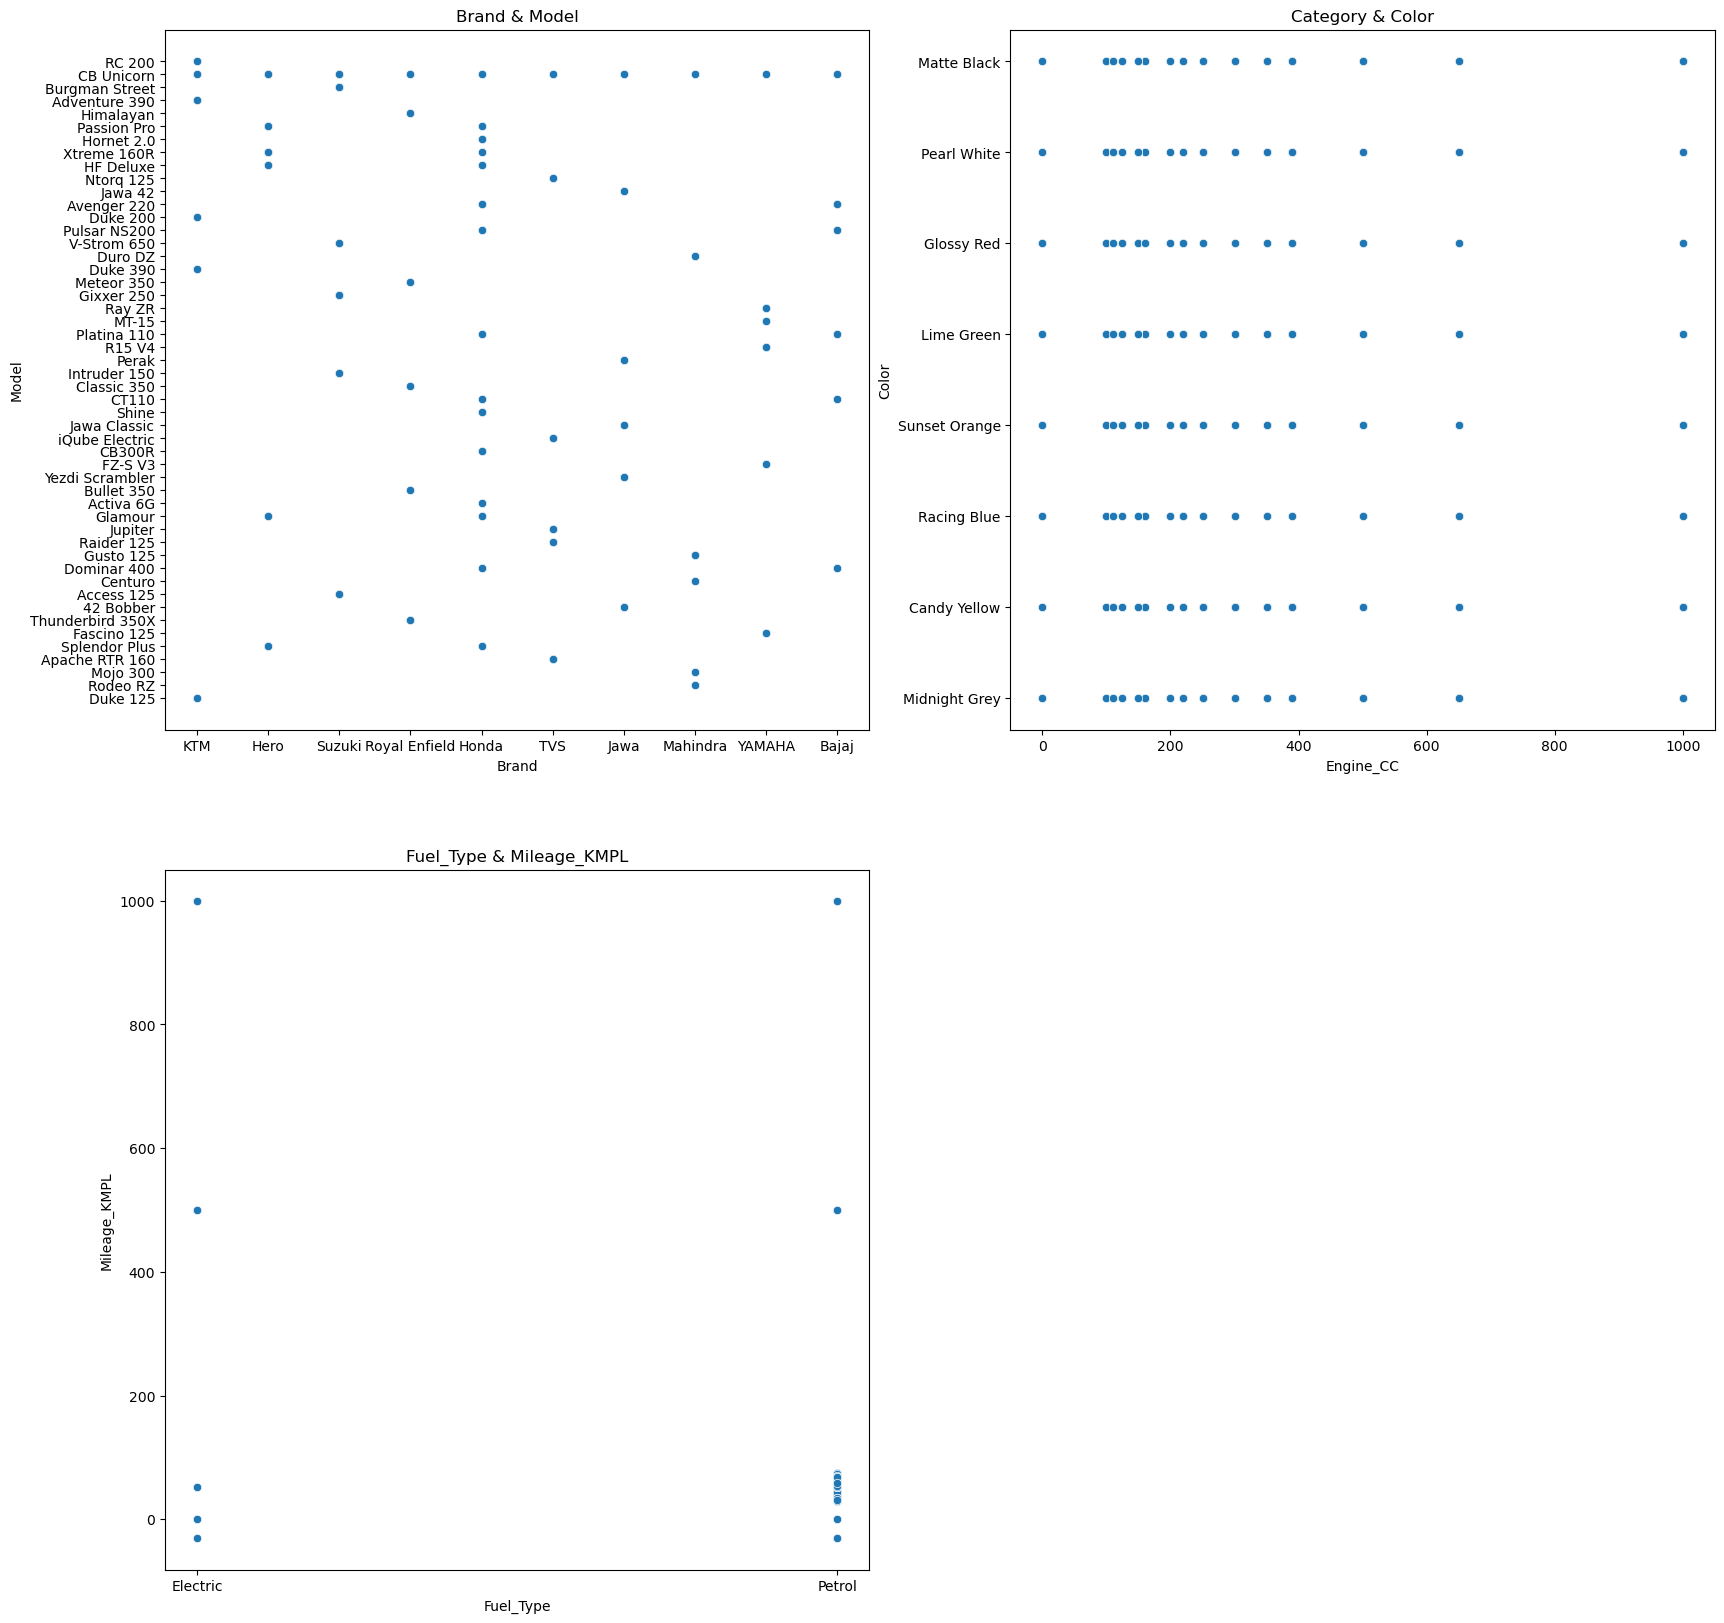

In [49]:
plt.figure(figsize=(20,20))
plt.subplot(221)
sns.scatterplot(x=df['Brand'],y=df['Model'])
plt.title('Brand & Model')

plt.subplot(222)
sns.scatterplot(x=df['Engine_CC'],y=df['Color'])
plt.title('Category & Color')

plt.subplot(223)
sns.scatterplot(x=df['Fuel_Type'],y=df['Mileage_KMPL'])
plt.title('Fuel_Type & Mileage_KMPL')

In [50]:
df.head()

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,52.2,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,CB Unicorn,Commuter,Pearl White,100,Electric,Manual,52.2,147600.0,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,5000.0,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4


In [51]:
'''plt.figure(figsize=(15,15))
# plot method
ax1=plt.subplot(331)
df.plot(kind='scatter',x='Order_ID',y='Sale_Date',color='blue',ax=ax1)
ax1.set_title("Order_ID & Sale_Date")

#m matplotlib
ax2=plt.subplot(332)
ax2.scatter(df['Brand'],df['Customer_Segment'],color='green')
ax2.set_title("Brand Vs Model")
ax2.set_xlabel("Brand")
ax2.set_ylabel("Model")


# seaborn
ax3=plt.subplot(333)
sns.scatterplot(data=df,x='Category',y='Color',color='red',ax=ax3)
ax3.set_title("Category & Color")

ax4=plt.subplot(334)
df.plot(kind='scatter',x='Engine_CC',y='Fuel_Type',color='black',ax=ax4)
ax4.set_title("Engine_CC & Fuel_Type")

ax5=plt.subplot(335)
ax5.scatter(df['Transmission'],df['Mileage_KMPL'],color='green')
ax5.set_title('Transmission & Mileage_KMPL')
ax5.set_xlabel("Transmission")
ax5.set_ylabel("Mileage_KMPL")

ax6=plt.subplot(336)
sns.scatterplot(data=df,x='Ex_Showroom_Price_INR',y='Discount_INR',color='purple',ax=ax6)
ax6.set_title('Ex_Showroom_Price_INR & Discount_INR')

ax7=plt.subplot(337)
sns.scatterplot(data=df,x='State',y='City',color='orange',ax=ax7)
ax7.set_title('State & City')

plt.tight_layout()'''

'plt.figure(figsize=(15,15))\n# plot method\nax1=plt.subplot(331)\ndf.plot(kind=\'scatter\',x=\'Order_ID\',y=\'Sale_Date\',color=\'blue\',ax=ax1)\nax1.set_title("Order_ID & Sale_Date")\n\n#m matplotlib\nax2=plt.subplot(332)\nax2.scatter(df[\'Brand\'],df[\'Customer_Segment\'],color=\'green\')\nax2.set_title("Brand Vs Model")\nax2.set_xlabel("Brand")\nax2.set_ylabel("Model")\n\n\n# seaborn\nax3=plt.subplot(333)\nsns.scatterplot(data=df,x=\'Category\',y=\'Color\',color=\'red\',ax=ax3)\nax3.set_title("Category & Color")\n\nax4=plt.subplot(334)\ndf.plot(kind=\'scatter\',x=\'Engine_CC\',y=\'Fuel_Type\',color=\'black\',ax=ax4)\nax4.set_title("Engine_CC & Fuel_Type")\n\nax5=plt.subplot(335)\nax5.scatter(df[\'Transmission\'],df[\'Mileage_KMPL\'],color=\'green\')\nax5.set_title(\'Transmission & Mileage_KMPL\')\nax5.set_xlabel("Transmission")\nax5.set_ylabel("Mileage_KMPL")\n\nax6=plt.subplot(336)\nsns.scatterplot(data=df,x=\'Ex_Showroom_Price_INR\',y=\'Discount_INR\',color=\'purple\',ax=ax6)\nax

## Bivariate Analysis

### 1. Relationship between Discount_INR and Ex_Showroom_Price_INR ?

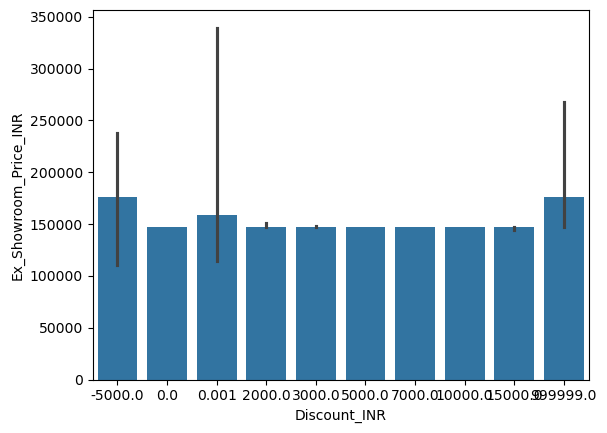

In [53]:
sns.barplot(data = df, x = 'Discount_INR', y = 'Ex_Showroom_Price_INR',estimator='median')
plt.show()

In [55]:
df.head()

,Order_ID,Sale_Date,Brand,Model,Category,Color,Engine_CC,Fuel_Type,Transmission,Mileage_KMPL,Ex_Showroom_Price_INR,Discount_INR,Units_Sold,Revenue_INR,State,City,Sales_Channel,Customer_Segment,Payment_Method,Customer_Rating
0,IND-16054,08-04-2022,KTM,RC 200,Electric,Matte Black,0,Electric,Manual,52.2,90400.0,2000.0,12,1060800,Maharashtra,Mumbai,Company Direct,Student,Cash,3.9
1,IND-20096,15-01-2024,Hero,CB Unicorn,Commuter,Pearl White,100,Electric,Manual,52.2,147600.0,0.0,14,1083600,Uttar Pradesh,Lucknow,Exchange,Delivery Executive,Credit Card,3.9
2,IND-10123,21-01-2023,Suzuki,Burgman Street,Adventure,Matte Black,300,Petrol,Manual,68.2,377700.0,5000.0,8,2901600,Maharashtra,Mumbai,Online,Student,Cash,4.6
3,IND-11202,04-03-2022,KTM,Adventure 390,Superbike,Glossy Red,1000,Petrol,Manual,45.3,451800.0,10000.0,11,4859800,Maharashtra,Mumbai,Exchange,Working Professional,Cash,4.8
4,IND-18840,29-08-2024,Royal Enfield,Himalayan,Adventure,Matte Black,650,Petrol,Manual,54.7,286300.0,7000.0,6,1675800,Uttar Pradesh,Lucknow,Online,Businessman,UPI,4.4


### 2. Bikes sold on the basis of '	Mileage_KMPL' and '	Brand' ?

In [90]:
ct = pd.crosstab(index = df['Ex_Showroom_Price_INR'],columns = df['Engine_CC'])

In [ ]:
ct.plot(kind = 'barh')
plt.xlabel('Bikes Sold')
plt.ylabel('Bike Company')
plt.tight_layout()
plt.show()

###  3. Skewness, Distribution between 'Brand' and 'Engine_CC' ?

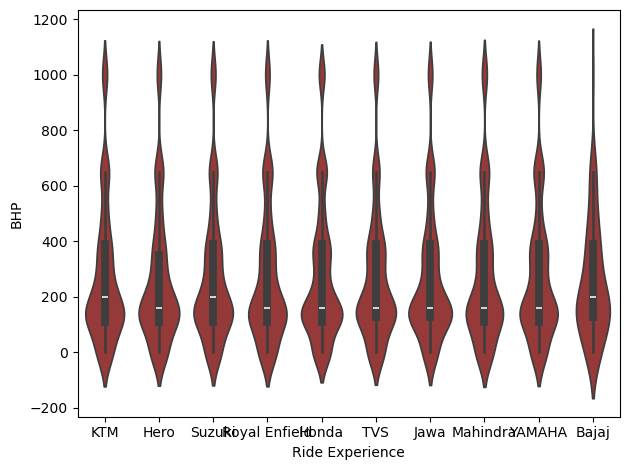

In [85]:
sns.violinplot(data = df,x = 'Brand', y= 'Engine_CC',color = 'brown')
plt.xlabel('Ride Experience')
plt.ylabel('BHP')
plt.tight_layout()

## 4. Relationship between 'Discount_INR' and 'Ex_Showroom_Price_INR' ?

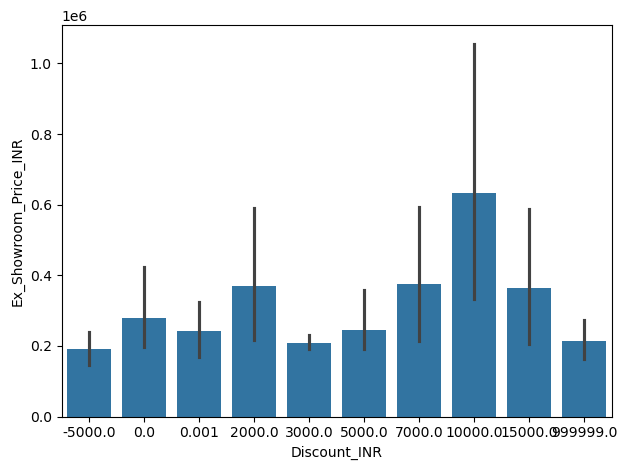

In [89]:
sns.barplot(data = df, x = 'Discount_INR', y = 'Ex_Showroom_Price_INR')
plt.xlabel('Discount_INR')
plt.ylabel('Ex_Showroom_Price_INR')
plt.tight_layout()

## 5. Total no.of bikes sold on the basis of 'Brand', 'Fuel_Type' and '	Ex_Showroom_Price_INR' ?

<Figure size 1000x800 with 0 Axes>

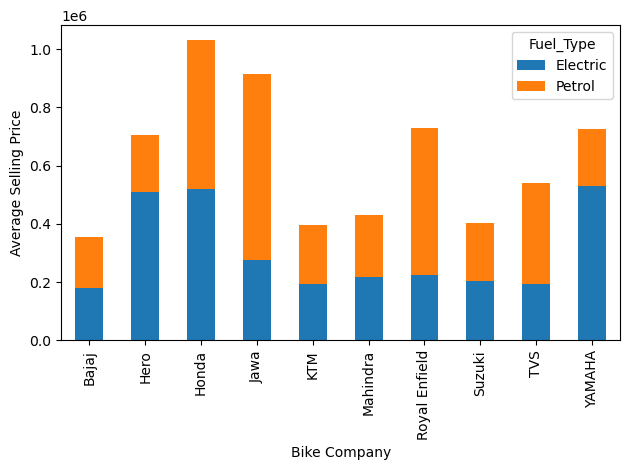

In [83]:
plt.figure(figsize=(10,8))
ct_mft =pd.crosstab(index = df['Brand'],columns = df['Fuel_Type'],values = df['Ex_Showroom_Price_INR'],aggfunc = 'mean')
ct_mft.plot(kind="bar",stacked=True)
plt.xlabel('Bike Company')
plt.ylabel('Average Selling Price')
plt.tight_layout()

# Multivariate

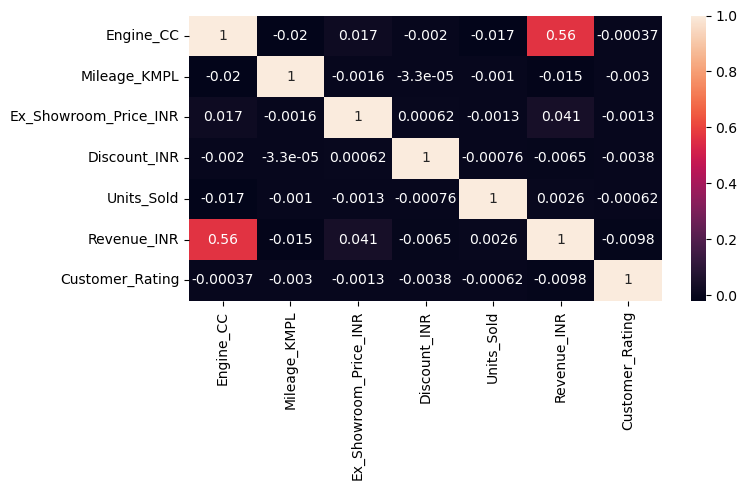

In [84]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot = True)
plt.tight_layout()